##**🧠Classical Machine Learning for NLP**

*   **(TF-IDF + Traditional Models)**



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

X_train= pd.read_csv('/content/drive/MyDrive/Hotel_Reviews_Project/X_train_clean.csv')
X_test= pd.read_csv('/content/drive/MyDrive/Hotel_Reviews_Project/X_test_clean.csv')

y_train= pd.read_csv('/content/drive/MyDrive/Hotel_Reviews_Project/y_train_clean.csv')
y_test= pd.read_csv('/content/drive/MyDrive/Hotel_Reviews_Project/y_test_clean.csv')

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((409555, 25), (102389, 25), (409555, 1), (102389, 1))

In [3]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [6]:
y_train.shape, y_test.shape

((409555,), (102389,))

#**Text Cleaning**

In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import stopwords
from string import punctuation

# Download necessary NLTK data
nltk.download(['stopwords', 'punkt_tab','averaged_perceptron_tagger_eng', 'wordnet'], quiet=True)

# تحميل مرة واحدة بس
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, include_html_tags=False):

    # handle null
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # remove "no positive / no negative"
    text = text.replace("no negative", "")
    text = text.replace("no positive", "")

    # remove numbers & symbols
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # POS tagging
    pos_tags = pos_tag(tokens)

    # Lemmatization
    lemmatized_tokens = []
    for word, tag in pos_tags:
        pos = tag[0].lower()
        if pos in ['a', 'r', 'n', 'v']:
            lemmatized_tokens.append(lemmatizer.lemmatize(word, pos))
        else:
            lemmatized_tokens.append(word)

    # Join text
    return " ".join(lemmatized_tokens)

In [ ]:
from tqdm import tqdm
tqdm.pandas()

# Train
X_train['full_review'] = X_train['full_review'].progress_apply(preprocess_text)

# Test
X_test['full_review'] = X_test['full_review'].progress_apply(preprocess_text)

100%|██████████| 102389/102389 [01:49<00:00, 936.13it/s] 


#**TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF object
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

# Fit on TRAIN only
X_train_text = tfidf.fit_transform(X_train['full_review'])

# Transform TEST only
X_test_text = tfidf.transform(X_test['full_review'])

# Check shape
print("Train TF-IDF shape:", X_train_text.shape)
print("Test TF-IDF shape:", X_test_text.shape)

Train TF-IDF shape: (409555, 5000)
Test TF-IDF shape: (102389, 5000)


In [ ]:
import joblib

joblib.dump(tfidf, '/content/drive/MyDrive/Hotel_Reviews_Project/tfidf.pkl')

['/content/drive/MyDrive/Hotel_Reviews_Project/tfidf.pkl']

In [ ]:
from scipy.sparse import hstack, csr_matrix

# drop text column
X_train_other = X_train.drop('full_review', axis=1)
X_test_other = X_test.drop('full_review', axis=1)

# convert to sparse
X_train_other = csr_matrix(X_train_other.values)
X_test_other = csr_matrix(X_test_other.values)

# merge everything
X_train_final = hstack([X_train_other, X_train_text])
X_test_final = hstack([X_test_other, X_test_text])

In [ ]:
from scipy import sparse

sparse.save_npz('/content/drive/MyDrive/Hotel_Reviews_Project/X_train_final.npz', X_train_final)
sparse.save_npz('/content/drive/MyDrive/Hotel_Reviews_Project/X_test_final.npz', X_test_final)

In [4]:
import pandas as pd
from scipy import sparse

X_train_final = sparse.load_npz('/content/drive/MyDrive/Hotel_Reviews_Project/X_train_final.npz')
X_test_final = sparse.load_npz('/content/drive/MyDrive/Hotel_Reviews_Project/X_test_final.npz')

#**🧠Classic ML Models**

#**LinearSVC**

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

model = LinearSVC()

model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8043832833605172
              precision    recall  f1-score   support

    negative       0.75      0.65      0.70     35734
    positive       0.83      0.88      0.85     66655

    accuracy                           0.80    102389
   macro avg       0.79      0.77      0.78    102389
weighted avg       0.80      0.80      0.80    102389



#**🧠 Deep Learning for NLP**
*   **(LSTM + Bidirectional LSTM Models)**

###*🥇 LinearSVC + GridSearchCV*

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

model = LinearSVC()

param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_final, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

y_pred = best_model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Parameters: {'C': 0.1}
Accuracy: 0.8117375889988182



Classification Report:

              precision    recall  f1-score   support

    negative       0.76      0.67      0.71     35734
    positive       0.83      0.89      0.86     66655

    accuracy                           0.81    102389
   macro avg       0.80      0.78      0.79    102389
weighted avg       0.81      0.81      0.81    102389



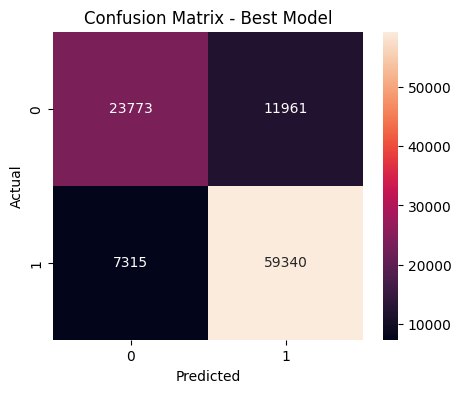

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# save model

import joblib
joblib.dump

joblib.dump(best_model, '/content/drive/MyDrive/Hotel_Reviews_Project/svc_model.pkl')

['/content/drive/MyDrive/Hotel_Reviews_Project/svc_model.pkl']

###*🟣 LSTM (Deep Learning for NLP)*

In [44]:
#1️⃣ Tokenizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train['full_review'])

X_train_seq = tokenizer.texts_to_sequences(X_train['full_review'])
X_test_seq = tokenizer.texts_to_sequences(X_test['full_review'])

#2️⃣ Padding

X_train_pad = pad_sequences(X_train_seq, maxlen=150, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=150, padding='post')

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=20000, output_dim=128),

    LSTM(64, return_sequences=False),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [46]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/Hotel_Reviews_Project/best_lstm_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [47]:
history = model.fit(
    X_train_pad,
    y_train_enc,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/10
2557/2560 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6554 - loss: 0.6457
Epoch 1: val_accuracy improved from None to 0.65292, saving model to /content/drive/MyDrive/Hotel_Reviews_Project/best_lstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Hotel_Reviews_Project/best_lstm_model.keras
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.6563 - loss: 0.6445 - val_accuracy: 0.6529 - val_loss: 0.6448
Epoch 2/10
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6674 - loss: 0.6284
Epoch 2: val_accuracy improved from 0.65292 to 0.80042, saving model to /content/drive/MyDrive/Hotel_Reviews_Project/best_lstm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Hotel_Reviews_Project/best_lstm_model.keras
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.7051 - loss: 0.5736 - val_accuracy: 0.8004 - val_loss: 0.4221
Epoch 3/10
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8128 - loss: 0.4088
Epoch 3: val

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step
LSTM Accuracy: 0.8103311879205775
              precision    recall  f1-score   support

           0       0.79      0.62      0.70     35734
           1       0.82      0.91      0.86     66655

    accuracy                           0.81    102389
   macro avg       0.80      0.77      0.78    102389
weighted avg       0.81      0.81      0.80    102389



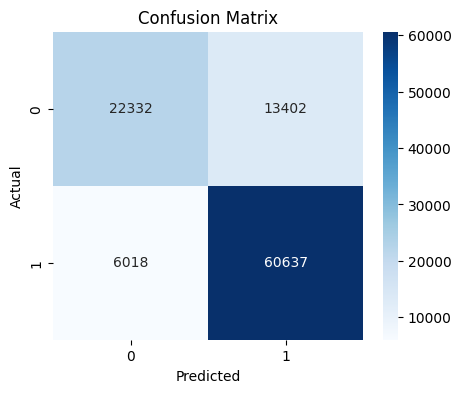

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test_pad) > 0.5).astype(int)

accuracy = accuracy_score(y_test_enc, y_pred)

print("LSTM Accuracy:", accuracy)

print(classification_report(y_test_enc, y_pred))

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

###*🧠  Bidirectional LSTM for Sentiment Analysis*

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(input_dim=20000, output_dim=128),

    Bidirectional(LSTM(64)),

    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [55]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/Hotel_Reviews_Project/best_bilstm_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [56]:
history = model.fit(
    X_train_pad,
    y_train_enc,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/10
2559/2560 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7792 - loss: 0.4580
Epoch 1: val_accuracy improved from None to 0.81097, saving model to /content/drive/MyDrive/Hotel_Reviews_Project/best_bilstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Hotel_Reviews_Project/best_bilstm_model.keras
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 80s 30ms/step - accuracy: 0.8003 - loss: 0.4261 - val_accuracy: 0.8110 - val_loss: 0.4095
Epoch 2/10
2559/2560 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8238 - loss: 0.3863
Epoch 2: val_accuracy improved from 0.81097 to 0.81291, saving model to /content/drive/MyDrive/Hotel_Reviews_Project/best_bilstm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Hotel_Reviews_Project/best_bilstm_model.keras
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 65s 25ms/step - accuracy: 0.8238 - loss: 0.3862 - val_accuracy: 0.8129 - val_loss: 0.4010
Epoch 3/10
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8368 - loss: 0.3633
Epoc

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step
BiLSTM Accuracy: 0.813339323560148
              precision    recall  f1-score   support

           0       0.74      0.71      0.73     35734
           1       0.85      0.87      0.86     66655

    accuracy                           0.81    102389
   macro avg       0.80      0.79      0.79    102389
weighted avg       0.81      0.81      0.81    102389

[[25343 10391]
 [ 8721 57934]]


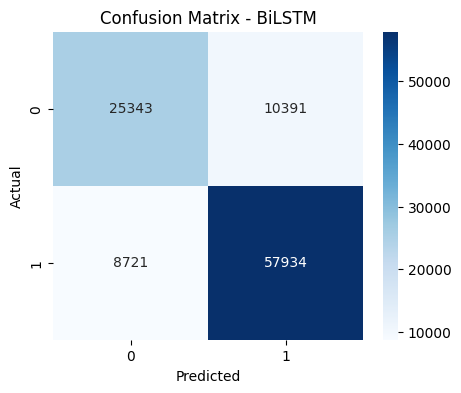

In [58]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test_pad) > 0.5).astype(int).flatten()
accuracy = accuracy_score(y_test_enc, y_pred)

print("BiLSTM Accuracy:", accuracy)

print(classification_report(y_test_enc, y_pred))

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_enc, y_pred)
print(cm)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - BiLSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 🏆 Best Model Selection

We compared multiple models on sentiment analysis:

- 🧠 LinearSVC: **~0.81 (Best overall)**
- 🔁 LSTM: **~0.80**
- 🔥 Bidirectional LSTM: **~0.81–0.812**

---

### 📌 Final Result:
✔️ Best Model: **LinearSVC (SVM)**  
✔️ Best Deep Learning Model: **Bidirectional LSTM**